<a href="https://colab.research.google.com/github/AaronYounger/Quantitative-Finance/blob/main/Factor_Construction%2C_Kalman_Filters%2C_Daubechies_Wavelets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# Install Packages
!pip install openbb
!pip install TA-LIB
!pip install pykalman
!pip install PyWavelets

In [5]:
from openbb import obb
import pandas as pd
import numpy as np
obb.user.preferences.output_type = "dataframe"
import matplotlib.pyplot as plt
from talib import RSI, BBANDS

In [16]:
# Get Data
symbols = ["AAPL", "TSLA", "JPM", "NVDA", "KO", "XOM", "NKE", "PFE", "DIS"]

daily_prices = obb.equity.price.historical(
    symbol=symbols,
    start_date="2015-01-01",
    end_date = "2026-03-01",
    provider = "yfinance",
    interval = "1d",
    auto_adjust = True
)


In [23]:
closing_price = daily_prices[["close", "symbol"]]

                 close symbol
date                         
2015-01-02   27.332500   AAPL
2015-01-02   93.750000    DIS
2015-01-02   62.490002    JPM
2015-01-02   42.139999     KO
2015-01-02   47.514999    NKE
...                ...    ...
2026-02-27   62.180000    NKE
2026-02-27  177.190002   NVDA
2026-02-27   27.650000    PFE
2026-02-27  402.510010   TSLA
2026-02-27  152.500000    XOM

[25245 rows x 2 columns]


In [36]:
# Change to DatetimeIndex
closing_price.index = pd.to_datetime(closing_price.index)
print(closing_price)

                 close symbol
date                         
2015-01-02   27.332500   AAPL
2015-01-02   93.750000    DIS
2015-01-02   62.490002    JPM
2015-01-02   42.139999     KO
2015-01-02   47.514999    NKE
...                ...    ...
2026-02-27   62.180000    NKE
2026-02-27  177.190002   NVDA
2026-02-27   27.650000    PFE
2026-02-27  402.510010   TSLA
2026-02-27  152.500000    XOM

[25245 rows x 2 columns]


In [47]:
#Resample data to monthly
monthly_prices = (closing_price.pivot(columns="symbol", values="close").resample("ME").last())

In [50]:
# Calculate Returns for Multiple Periods
data = pd.DataFrame()
lags = [1, 2, 3, 6, 12]
for lag in lags:
  data[f"return{lag}_m"] = (monthly_prices
                           .pct_change(lag)
                           .stack()
                           .add(1)
                           .pow(1 / lag)
                           .sub(1))
data = data.swaplevel().dropna().sort_index()
data.info()




<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1098 entries, ('AAPL', Timestamp('2016-01-31 00:00:00')) to ('XOM', Timestamp('2026-02-28 00:00:00'))
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   return1_m   1098 non-null   float64
 1   return2_m   1098 non-null   float64
 2   return3_m   1098 non-null   float64
 3   return6_m   1098 non-null   float64
 4   return12_m  1098 non-null   float64
dtypes: float64(5)
memory usage: 51.7+ KB
                   return1_m  return2_m  return3_m  return6_m  return12_m
symbol date                                                              
AAPL   2016-01-31  -0.075242  -0.092904  -0.066084  -0.036012   -0.015326
       2016-02-29  -0.006678  -0.041573  -0.065027  -0.025300   -0.023398
       2016-03-31   0.127211   0.058151   0.011675  -0.001989   -0.010980
       2016-04-30  -0.139921  -0.015373  -0.012483  -0.039657   -0.023795
       2016-05-31   0.065287  -0.042801   0

In [53]:
# Momentum factor construction
for lag in [2, 3, 6, 12]:
  data[f"momentum_{lag}"] = data[f"return{lag}_m"].sub(data.return1_m)

# Difference beteween 3 and 12 month returns
data[f'momentum_3_12'] = data['return12_m'].sub(data.return3_m)

print(data)

                   return1_m  return2_m  return3_m  return6_m  return12_m  \
symbol date                                                                 
AAPL   2016-01-31  -0.075242  -0.092904  -0.066084  -0.036012   -0.015326   
       2016-02-29  -0.006678  -0.041573  -0.065027  -0.025300   -0.023398   
       2016-03-31   0.127211   0.058151   0.011675  -0.001989   -0.010980   
       2016-04-30  -0.139921  -0.015373  -0.012483  -0.039657   -0.023795   
       2016-05-31   0.065287  -0.042801   0.010811  -0.027847   -0.021916   
...                      ...        ...        ...        ...         ...   
XOM    2025-10-31   0.014279   0.000306   0.008056   0.013323   -0.001744   
       2025-11-30   0.013641   0.013960   0.004732   0.021050   -0.001453   
       2025-12-31   0.038130   0.025812   0.021954   0.018510    0.009392   
       2026-01-31   0.175004   0.104449   0.073310   0.040171    0.023638   
       2026-02-28   0.078501   0.125719   0.095731   0.049245    0.026569   

In [63]:
# Rank stocks by 12 month return per monnth
data["rank_12m_returns"] = data.groupby("date")["return12_m"].rank(ascending=False, pct=True)
print(data["rank_12m_returns"])


symbol  date      
AAPL    2016-01-31    1.000000
        2016-02-29    1.000000
        2016-03-31    0.888889
        2016-04-30    1.000000
        2016-05-31    1.000000
                        ...   
XOM     2025-10-31    0.777778
        2025-11-30    0.666667
        2025-12-31    0.444444
        2026-01-31    0.222222
        2026-02-28    0.333333
Name: rank_12m_returns, Length: 1098, dtype: float64


In [68]:
# rank stocks by average 12-month return
avg_returns = data.groupby("symbol")["return12_m"].mean()
rank = avg_returns.sort_values(ascending=False).rank(pct=True)
print(rank)

symbol
NVDA    1.000000
TSLA    0.888889
AAPL    0.777778
JPM     0.666667
KO      0.555556
XOM     0.444444
NKE     0.333333
DIS     0.222222
PFE     0.111111
Name: return12_m, dtype: float64


In [74]:
# Adding time indicators
dates = data.index.get_level_values("date")
data['year'] = dates.year
data['month'] = dates.month
print(data)


                   return1_m  return2_m  return3_m  return6_m  return12_m  \
symbol date                                                                 
AAPL   2016-01-31  -0.075242  -0.092904  -0.066084  -0.036012   -0.015326   
       2016-02-29  -0.006678  -0.041573  -0.065027  -0.025300   -0.023398   
       2016-03-31   0.127211   0.058151   0.011675  -0.001989   -0.010980   
       2016-04-30  -0.139921  -0.015373  -0.012483  -0.039657   -0.023795   
       2016-05-31   0.065287  -0.042801   0.010811  -0.027847   -0.021916   
...                      ...        ...        ...        ...         ...   
XOM    2025-10-31   0.014279   0.000306   0.008056   0.013323   -0.001744   
       2025-11-30   0.013641   0.013960   0.004732   0.021050   -0.001453   
       2025-12-31   0.038130   0.025812   0.021954   0.018510    0.009392   
       2026-01-31   0.175004   0.104449   0.073310   0.040171    0.023638   
       2026-02-28   0.078501   0.125719   0.095731   0.049245    0.026569   

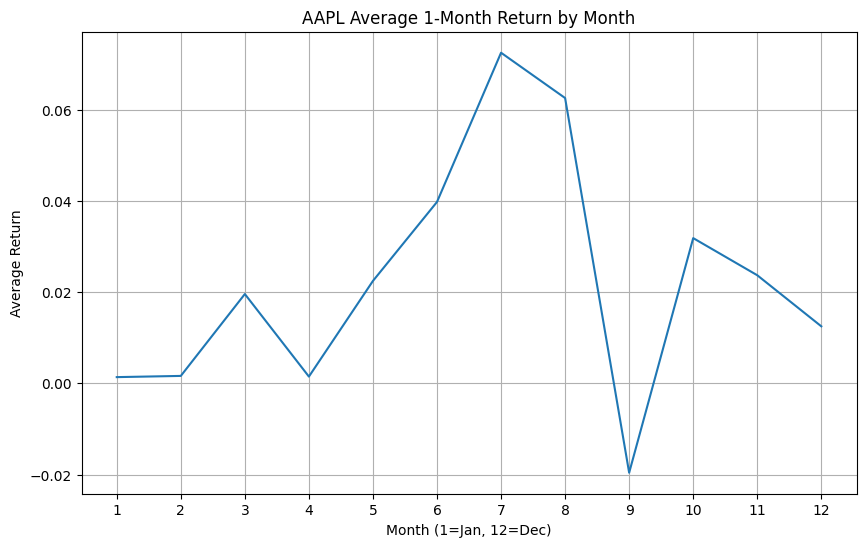

In [83]:
# Hypothesis: January holds higher returns than other months
aapl = data.loc["AAPL"].copy()
monthly_avg = aapl.groupby("month")["return1_m"].mean()

# Plot

plt.figure(figsize=(10,6))
plt.plot(monthly_avg.index, monthly_avg.values)

plt.title("AAPL Average 1-Month Return by Month")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.ylabel("Average Return")

plt.xticks(range(1,13))
plt.grid(True)

plt.show()

Using TA-Lib to create technical alpha factors
1.  Bollinger Bands
2.  Relative strength index

In [8]:
# Get Data
df = obb.equity.price.historical(
    symbol="AMD",
    start_date="2023-01-01",
    end_date = "2026-03-01",
    provider = "yfinance",
    interval = "1d",
    auto_adjust = True
)


                  open        high         low       close    volume
date                                                                
2023-01-03   66.000000   66.879997   63.590000   64.019997  46851800
2023-01-04   65.000000   65.790001   63.310001   64.660004  47477100
2023-01-05   64.150002   64.349998   62.299999   62.330002  46159500
2023-01-06   63.150002   64.300003   60.049999   63.959999  70161300
2023-01-09   66.220001   69.320000   65.669998   67.239998  69741300
...                ...         ...         ...         ...       ...
2026-02-23  198.089996  199.380005  194.149994  196.600006  28187900
2026-02-24  211.630005  216.710007  206.500000  213.839996  81367000
2026-02-25  214.820007  216.699997  210.330002  210.860001  44588100
2026-02-26  208.800003  209.789993  201.460007  203.679993  35020500
2026-02-27  200.110001  201.889999  197.740005  200.210007  31312400

[791 rows x 5 columns]


In [11]:
# Turn index into DatetimeIndex
df.index = pd.to_datetime(df.index)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 791 entries, 2023-01-03 to 2026-02-27
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    791 non-null    float64
 1   high    791 non-null    float64
 2   low     791 non-null    float64
 3   close   791 non-null    float64
 4   volume  791 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 37.1 KB


In [19]:
# Create 1D for indicators
df_close = df['close']

(791,)

In [20]:
up, mid, low = BBANDS(df_close, timeperiod=21, nbdevup=2, nbdevdn=2,
                      matype=0)
rsi = RSI(df_close, timeperiod=14)

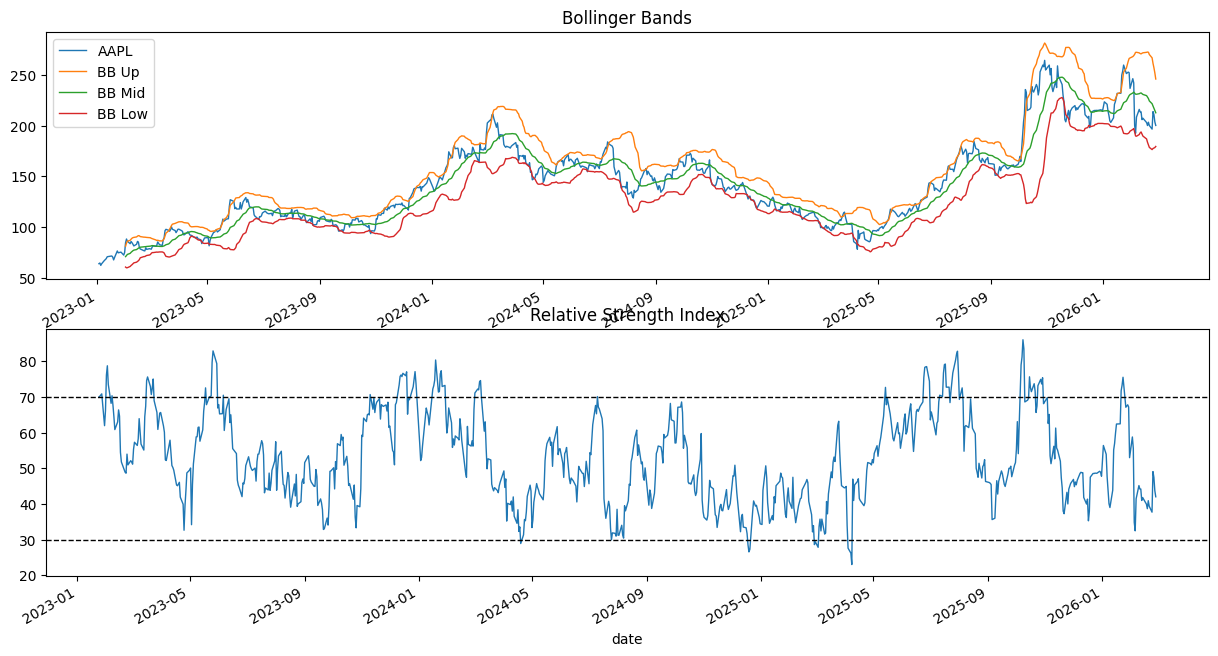

In [21]:
data = pd.DataFrame({
    'AAPL': df_close,
    'BB Up':up,
    'BB Mid':mid,
    'BB Low':low,
    'RSI':rsi
})

fig, axes= plt.subplots(nrows=2, figsize=(15, 8))
data.drop('RSI', axis=1).plot(ax=axes[0], lw=1, title='Bollinger Bands')
data['RSI'].plot(ax=axes[1], lw=1, title='Relative Strength Index')
axes[1].axhline(70, lw=1, ls='--', c='k')
axes[1].axhline(30, lw=1, ls='--', c='k')

**Denoising alpha factors with the Kalman filter**

The concept of noise in data relates to the domain of signal processing, which aims to retrieve the correct information from a signal sent.

Assumptions of the Kalman filter:
- The system that we are modelinng behaves in a linear fashion
- The hidden state process is a Markov chainn so that the current hidden state Xt depends only on the most recent prior hiden state Xt-1.
- Measuremennts are subject to Gaussian, uncorrelated noise with a constant variance.

Key disadvantages are the assumptions of linearity and Gaussian noise that financial data often violate. To address these shortcomings, the Kalman filter has been extended to systems with nonlinear dynamics in the form of the extended and the unscented Kalman filters. The **particle filter** is an alternative approach that uses sampling-based Monte Carlo approaches to estimate non-normal distributions.

Come back to the paricle filter.

In [26]:
# Import kalman Filter Package
from pykalman import KalmanFilter

In [24]:
# Get Data
sp500 = obb.equity.price.historical(
    symbol="SPY",
    start_date="2024-01-01",
    end_date = "2026-01-01",
    provider = "yfinance",
    interval = "1d",
    auto_adjust = True
)

                  open        high         low       close     volume  \
date                                                                    
2024-01-02  472.160004  473.670013  470.489990  472.649994  123623700   
2024-01-03  470.429993  471.190002  468.170013  468.790009  103585900   
2024-01-04  468.299988  470.959991  467.049988  467.279999   84232200   
2024-01-05  467.489990  470.440002  466.429993  467.920013   86118900   
2024-01-08  468.429993  474.750000  468.299988  474.600006   74879100   
...                ...         ...         ...         ...        ...   
2025-12-24  687.950012  690.830017  687.799988  690.380005   39445600   
2025-12-26  690.640015  691.659973  689.270020  690.309998   41613300   
2025-12-29  687.539978  689.200012  686.070007  687.849976   62559500   
2025-12-30  687.450012  688.559998  686.580017  687.010010   47160700   
2025-12-31  687.140015  687.359985  681.710022  681.919983   74144800   

            dividend  
date                  
2024

In [27]:
# Create Kalman Filter
kf = KalmanFilter(transition_matrices=[1],
                  observation_matrices = [1],
                  initial_state_mean= 0,
                  initial_state_covariance=1,
                  observation_covariance=1,
                  transition_covariance=.01)

state_means, _ = kf.filter(sp500['close'])

In [37]:
# Put results into a DataFrame
sp500_smoothed = sp500[['close']].copy()
sp500_smoothed['Kalman Filter'] = state_means

                 close  Kalman Filter
date                                 
2024-01-02  472.649994     236.324997
2024-01-03  468.790009     314.839670
2024-01-04  467.279999     354.172585
2024-01-05  467.920013     378.215376
2024-01-08  474.600006     395.684828


In [38]:
# Create Moving Averages to Compare
for i in [1, 2, 3]:
  sp500_smoothed[f"MA ({i} months)"] = (sp500_smoothed['close'].rolling(window=i * 21).mean())


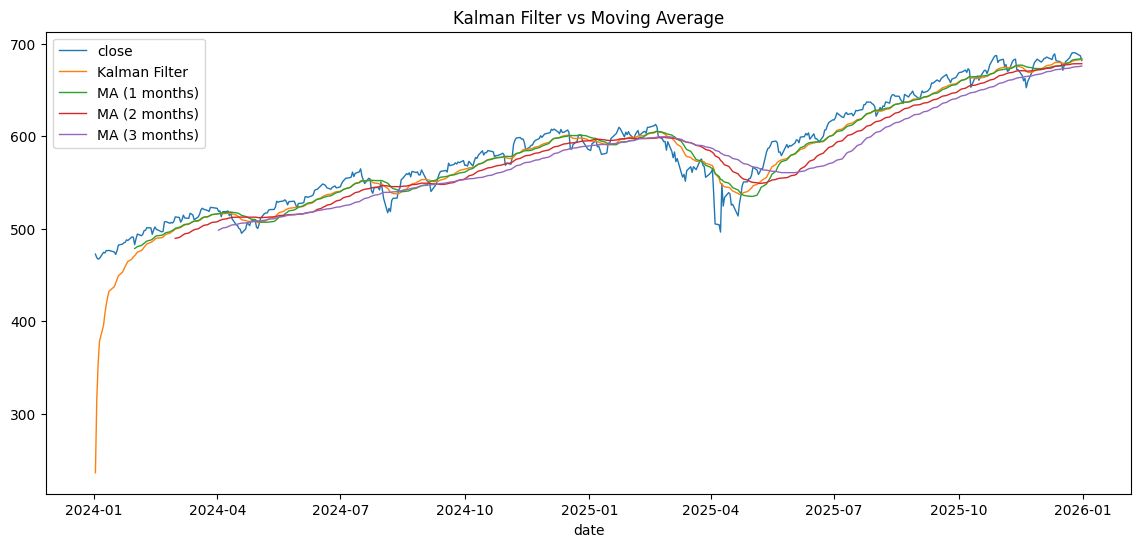

In [40]:
# Plot Kalman + Moving Averages
ax = sp500_smoothed.plot(title='Kalman Filter vs Moving Average',
 figsize=(14, 6), lw=1, rot=0)

**How to preprocess your noisy signals using wavelets**

To denoise a signal, you can use wavelet shrinkage and thresholding methods. First, you choose a specific wavelet pattern to decompose a dataset. The wavelet transform yields coefficients that correspond to details in the dataset.

The idea of thresholding is simply to omit all coefficients below a particular cutoff, assuming that they represent minor details that are not necessary to represent the true
signal. These remaining coefficients are then used in an inverse wavelet transformation to reconstruct the (denoised) dataset.

In [74]:
# Get Data
signal = obb.equity.price.historical(
    symbol="SPY",
    start_date="2024-01-01",
    end_date="2026-01-01",
    provider="yfinance",
    interval="1d",
    auto_adjust=True
)

signal['returns'] = signal['close'].pct_change().dropna()

In [75]:
# Explore wavelet families
import pywt
pywt.families(short=False)

['Haar',
 'Daubechies',
 'Symlets',
 'Coiflets',
 'Biorthogonal',
 'Reverse biorthogonal',
 'Discrete Meyer (FIR Approximation)',
 'Gaussian',
 'Mexican hat wavelet',
 'Morlet wavelet',
 'Complex Gaussian wavelets',
 'Shannon wavelets',
 'Frequency B-Spline wavelets',
 'Complex Morlet wavelets']

In [76]:
# Dataset with just returns
signal_wave = signal['returns'].dropna()
signal_wave.shape

(501,)

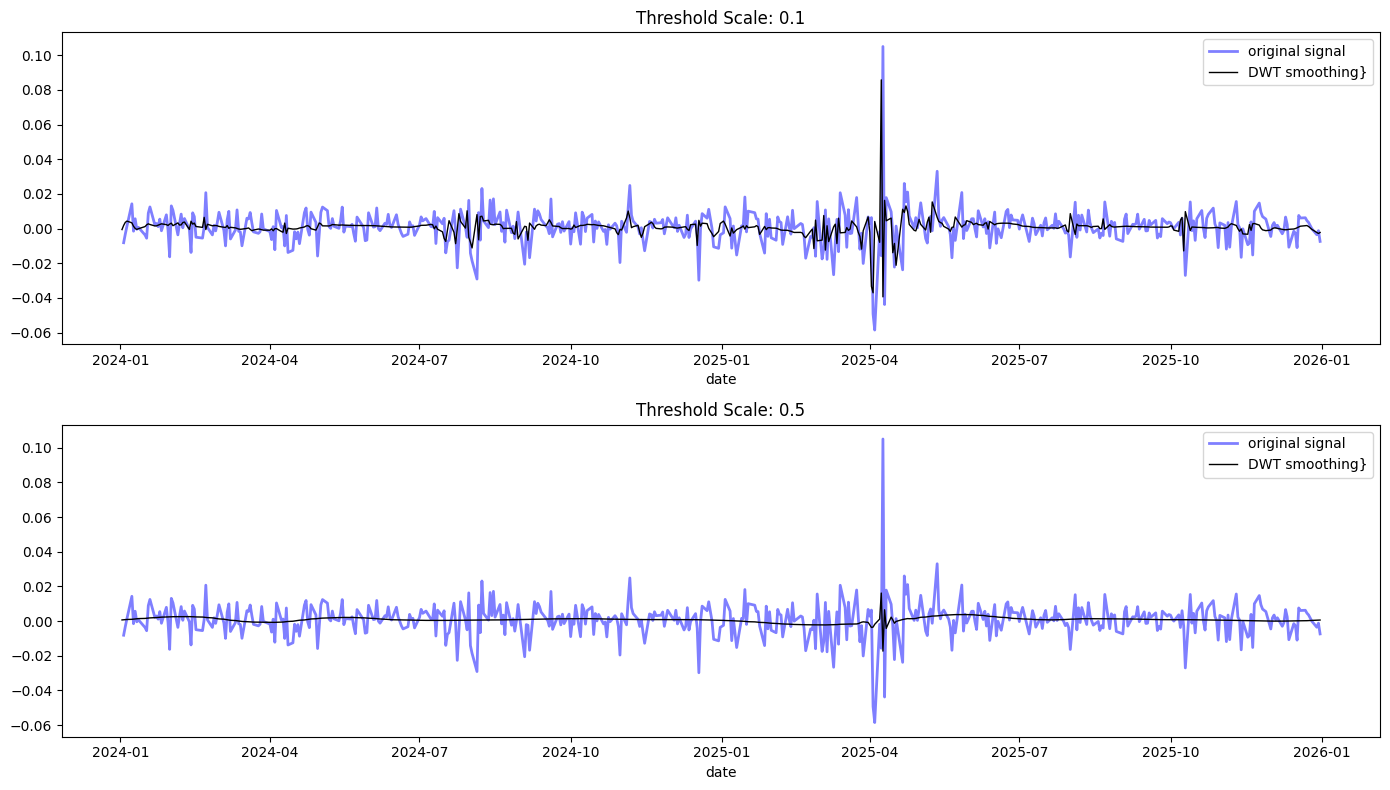

In [78]:
# Create db6 wave length with threshold value of 0.1 and 0.5

fig, axes = plt.subplots(nrows=2, figsize=(14, 8))

wavelet = "db6"
for i, scale in enumerate([0.1, 0.5]):
  coefficients = pywt.wavedec(signal_wave, wavelet, mode = 'per')
  coefficients[1:] = [pywt.threshold(c, value = scale*signal_wave.max(), mode='soft') for c in coefficients[1:]]
  reconstructed_signal = pywt.waverec(coefficients, wavelet, mode='per')
  # Plot
  signal_wave.plot(color="b", alpha=0.5, label='original signal', lw=2,
                title=f'Threshold Scale: {scale:.1f}', ax=axes[i])
  pd.Series(reconstructed_signal, index=signal.index).plot(c='k',
  label='DWT smoothing}', linewidth=1, ax=axes[i])
  axes[i].legend()

fig.tight_layout()
plt.show()